In [1]:
from typing import TypedDict

from langgraph.graph import StateGraph

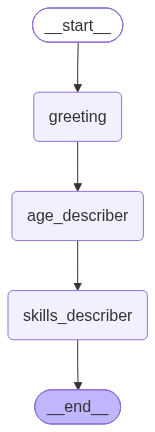

In [3]:
class AgentState(TypedDict):
    name: str
    age: int
    skills: list[str]
    result: str
    
def greeting_node(state: AgentState) -> AgentState:
    state['result'] = f"{state['name']}, welcome to this useless system! "
    return state
    
def age_describer_node(state: AgentState) -> AgentState:
    state['result'] += f"You are {state['age']} years old! "
    return state
    
def skills_describer_node(state: AgentState) -> AgentState:
    state['result'] += f"You have skills in {', '.join(state['skills'])}"
    return state
    
graph = StateGraph(AgentState)

graph.add_node("greeting", greeting_node)
graph.add_node("age_describer", age_describer_node)
graph.add_node("skills_describer", skills_describer_node)

graph.set_entry_point("greeting")
graph.add_edge("greeting", "age_describer")
graph.add_edge("age_describer", "skills_describer")
graph.set_finish_point("skills_describer")

app = graph.compile()
app

In [4]:
result = app.invoke(AgentState(name="Zeyad", age=25, skills=["Python", "JavaScript"], result=""))
result['result']

'Zeyad, welcome to this useless system! You are 25 years old! You have skills in Python, JavaScript'